<a href="https://colab.research.google.com/github/Danielw121/T-cnicas-XAI/blob/main/Tecnicas_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 XAI – Explicabilidad en Modelos de Crédito Bancario

**Dataset:** `Creditos_Bancarios.csv`  
**Objetivo:** Entrenar un modelo de ML, aplicar técnicas XAI (SHAP, LIME, PDP, Importancia de Variables) y reflexionar sobre la transparencia y ética del sistema.

---
## 📋 Tabla de Contenidos
1. Instalación de dependencias
2. Carga y exploración del dataset
3. Análisis de calidad de datos y detección de sesgos
4. Preprocesamiento
5. Entrenamiento del modelo (Random Forest + Regresión Logística)
6. Evaluación del modelo
7. Técnicas XAI
   - 7.1 Importancia de variables (Permutation Feature Importance)
   - 7.2 SHAP (Shapley Values)
   - 7.3 LIME
   - 7.4 Partial Dependence Plots (PDP)
8. Explicaciones individuales de predicciones
9. Análisis ético e interpretativo
10. Reflexión final


## 1. Instalación de Dependencias


In [1]:
# Instalar librerías necesarias
!pip install shap lime scikit-learn pandas numpy matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# Importaciones generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# XAI
import shap
from lime import lime_tabular

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

## 2. Carga y Exploración del Dataset


In [6]:
df = pd.read_csv('Creditos_Bancarios.csv')
print(f'Dimensiones del dataset: {df.shape}')
print(f'Variable objetivo: resultado_credito_anterior')
print(f'Distribución: {df["resultado_credito_anterior"].value_counts().to_dict()}')
df.head(10)

Dimensiones del dataset: (1500, 9)
Variable objetivo: resultado_credito_anterior
Distribución: {1: 966, 0: 534}


,edad,ingresos,educacion,zona,historial_crediticio,estado_civil,sexo,ocupacion,resultado_credito_anterior
0,32,2125.17,Postgrado,Urbana,Regular,Casado,Masculino,Independiente,1
1,56,453.44,Universitaria,Urbana,Regular,Casado,Masculino,Independiente,0
2,38,641.41,Secundaria,Periferia,Regular,Casado,Masculino,Empleado,0
3,41,1372.61,Secundaria,Periferia,Regular,Casado,Masculino,Empleado,1
4,38,2823.95,Primaria,Urbana,Bueno,Soltero,Femenino,Empleado,1
5,45,4253.27,Secundaria,Urbana,Bueno,Casado,Femenino,Empleado,1
6,32,1028.01,Universitaria,Urbana,Bueno,Soltero,Masculino,Desempleado,1
7,55,300.00,Secundaria,Urbana,Bueno,Casado,Femenino,Desempleado,1
8,63,940.70,Secundaria,Periferia,Bueno,Casado,Femenino,Desempleado,0
9,56,2054.35,Secundaria,Rural,Bueno,Soltero,Masculino,Empleado,1


In [8]:
# Información general del dataset
print('Tipos de datos y valores nulos')
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Únicos': df.nunique()
})
display(info_df)

print('\n Estadísticas descriptivas')
display(df.describe())

Tipos de datos y valores nulos


,Tipo,Nulos,Únicos
edad,int64,0,47
ingresos,float64,0,1427
educacion,object,0,4
zona,object,0,3
historial_crediticio,object,0,3
estado_civil,object,0,3
sexo,object,0,2
ocupacion,object,0,3
resultado_credito_anterior,int64,0,2



 Estadísticas descriptivas


,edad,ingresos,resultado_credito_anterior
count,1500.000000,1500.000000,1500.000000
mean,40.417333,2003.127147,0.644000
std,13.792340,968.131070,0.478975
min,18.000000,300.000000,0.000000
25%,28.000000,1339.837500,0.000000
50%,40.000000,1992.605000,1.000000
75%,52.000000,2598.440000,1.000000
max,64.000000,5576.510000,1.000000


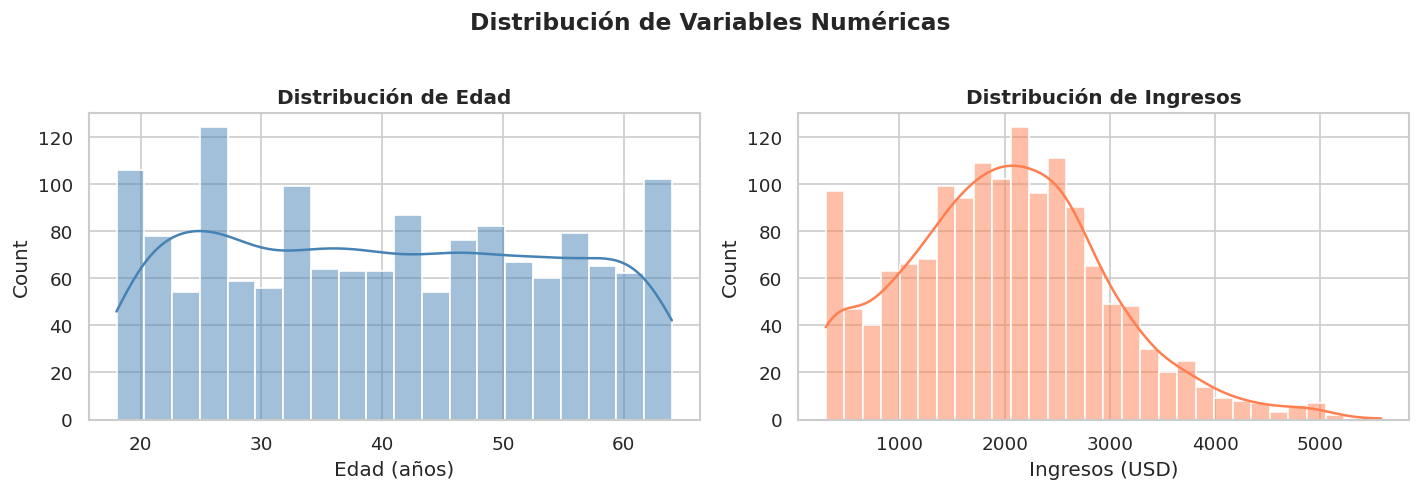

In [9]:
# Visualización de distribuciones numéricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['edad'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Edad', fontweight='bold')
axes[0].set_xlabel('Edad (años)')

sns.histplot(df['ingresos'], bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribución de Ingresos', fontweight='bold')
axes[1].set_xlabel('Ingresos (USD)')

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

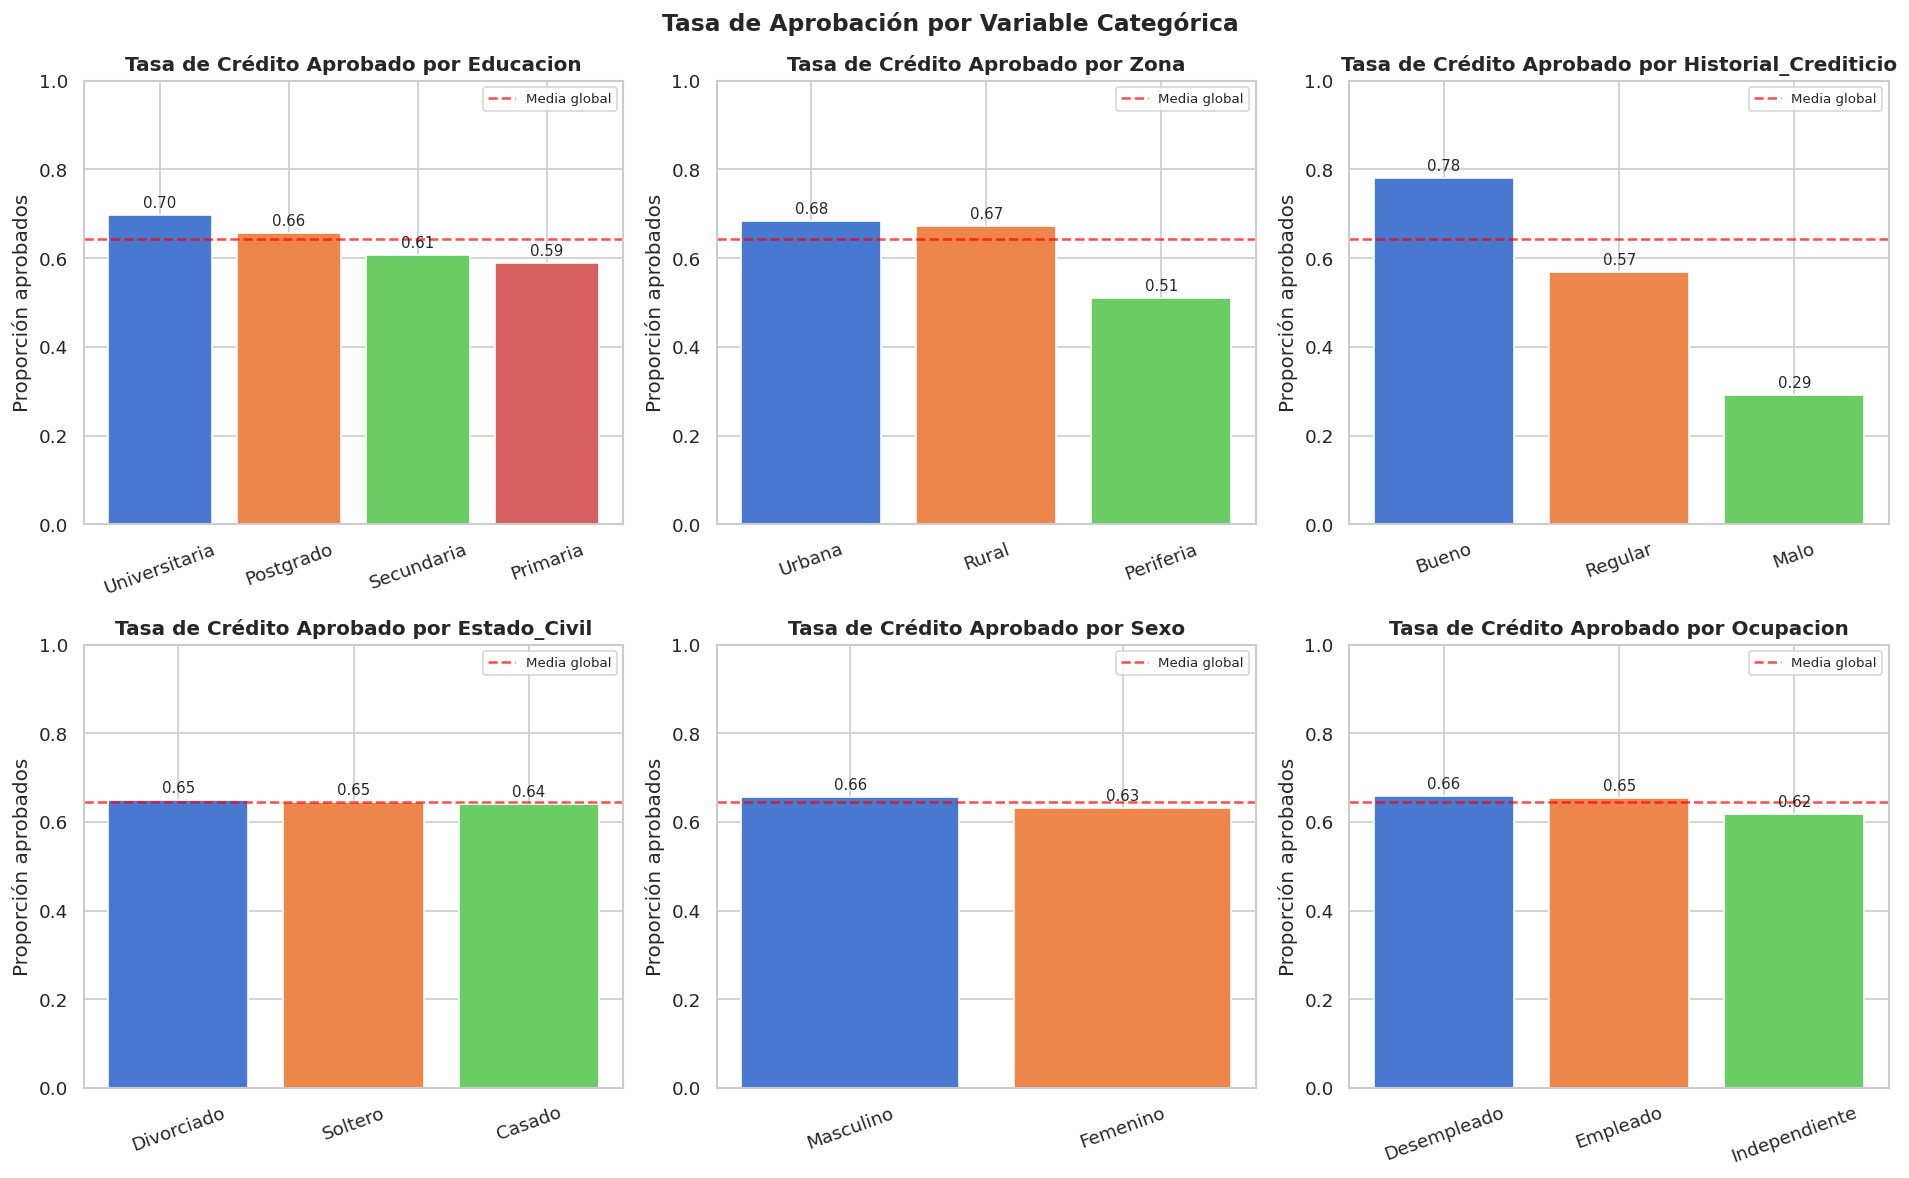

In [10]:
# Distribución de variables categóricas vs variable objetivo
cat_cols = ['educacion', 'zona', 'historial_crediticio', 'estado_civil', 'sexo', 'ocupacion']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    prop = df.groupby(col)['resultado_credito_anterior'].mean().sort_values(ascending=False)
    bars = axes[i].bar(prop.index, prop.values, color=sns.color_palette('muted', len(prop)))
    axes[i].set_title(f'Tasa de Crédito Aprobado por {col.title()}', fontweight='bold')
    axes[i].set_ylabel('Proporción aprobados')
    axes[i].set_ylim(0, 1)
    axes[i].axhline(y=df['resultado_credito_anterior'].mean(), color='red', linestyle='--', alpha=0.7, label='Media global')
    for bar, val in zip(bars, prop.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Tasa de Aprobación por Variable Categórica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Análisis de Calidad de Datos y Detección de Sesgos


In [12]:
print('ANÁLISIS DE CALIDAD DE DATOS')
print(f'\n1. Valores nulos: {df.isnull().sum().sum()} (dataset limpio)')
print(f'2. Duplicados: {df.duplicated().sum()}')
print(f'3. Balance de clases:')
vc = df['resultado_credito_anterior'].value_counts(normalize=True)
print(f'   Aprobado (1): {vc[1]:.1%} | Rechazado (0): {vc[0]:.1%}')

print('\n ANÁLISIS DE SESGO (FAIRNESS)')
# Análisis de sesgo por sexo
print('\n Tasa de aprobación por SEXO:')
sesgo_sexo = df.groupby('sexo').agg(
    total=('resultado_credito_anterior', 'count'),
    aprobados=('resultado_credito_anterior', 'sum')
).assign(tasa=lambda x: x.aprobados / x.total)
print(sesgo_sexo)

print('\n Tasa de aprobación por ZONA:')
sesgo_zona = df.groupby('zona').agg(
    total=('resultado_credito_anterior', 'count'),
    aprobados=('resultado_credito_anterior', 'sum')
).assign(tasa=lambda x: x.aprobados / x.total)
print(sesgo_zona)

print('\n Tasa de aprobación por EDUCACIÓN:')
sesgo_edu = df.groupby('educacion').agg(
    total=('resultado_credito_anterior', 'count'),
    aprobados=('resultado_credito_anterior', 'sum')
).assign(tasa=lambda x: x.aprobados / x.total)
print(sesgo_edu)

ANÁLISIS DE CALIDAD DE DATOS

1. Valores nulos: 0 (dataset limpio)
2. Duplicados: 0
3. Balance de clases:
   Aprobado (1): 64.4% | Rechazado (0): 35.6%

 ANÁLISIS DE SESGO (FAIRNESS)

 Tasa de aprobación por SEXO:
           total  aprobados      tasa
sexo                                 
Femenino     741        468  0.631579
Masculino    759        498  0.656126

 Tasa de aprobación por ZONA:
           total  aprobados      tasa
zona                                 
Periferia    331        169  0.510574
Rural        275        185  0.672727
Urbana       894        612  0.684564

 Tasa de aprobación por EDUCACIÓN:
               total  aprobados      tasa
educacion                                
Postgrado        221        145  0.656109
Primaria         139         82  0.589928
Secundaria       620        376  0.606452
Universitaria    520        363  0.698077


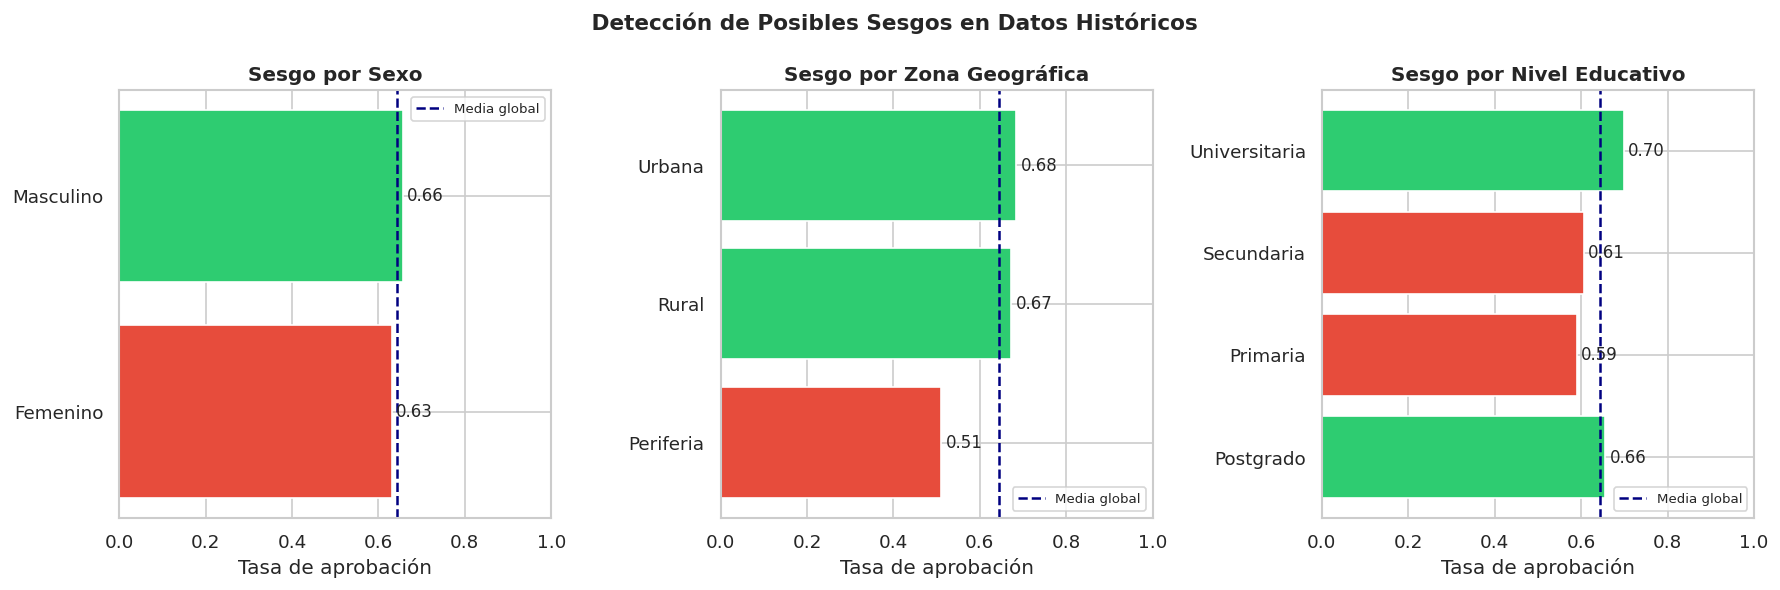

In [14]:
# Visualización de sesgo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, title) in zip(axes, [('sexo', 'Sexo'), ('zona', 'Zona Geográfica'), ('educacion', 'Nivel Educativo')]):
    data = df.groupby(col)['resultado_credito_anterior'].mean()
    colors = ['#2ecc71' if v >= df['resultado_credito_anterior'].mean() else '#e74c3c' for v in data.values]
    bars = ax.barh(data.index, data.values, color=colors, edgecolor='white')
    ax.axvline(x=df['resultado_credito_anterior'].mean(), color='navy', linestyle='--', linewidth=1.5, label='Media global')
    ax.set_title(f'Sesgo por {title}', fontweight='bold')
    ax.set_xlabel('Tasa de aprobación')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(' Detección de Posibles Sesgos en Datos Históricos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Preprocesamiento


In [15]:
# Codificación de variables categóricas
df_model = df.copy()

# Label Encoding para variables categóricas
le_dict = {}
cat_cols = ['educacion', 'zona', 'historial_crediticio', 'estado_civil', 'sexo', 'ocupacion']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Features y target
feature_names = ['edad', 'ingresos', 'educacion', 'zona', 'historial_crediticio',
                 'estado_civil', 'sexo', 'ocupacion']
X = df_model[feature_names]
y = df_model['resultado_credito_anterior']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar para regresión logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'\n Train: {X_train.shape} | Test: {X_test.shape}')

educacion: {'Postgrado': np.int64(0), 'Primaria': np.int64(1), 'Secundaria': np.int64(2), 'Universitaria': np.int64(3)}
zona: {'Periferia': np.int64(0), 'Rural': np.int64(1), 'Urbana': np.int64(2)}
historial_crediticio: {'Bueno': np.int64(0), 'Malo': np.int64(1), 'Regular': np.int64(2)}
estado_civil: {'Casado': np.int64(0), 'Divorciado': np.int64(1), 'Soltero': np.int64(2)}
sexo: {'Femenino': np.int64(0), 'Masculino': np.int64(1)}
ocupacion: {'Desempleado': np.int64(0), 'Empleado': np.int64(1), 'Independiente': np.int64(2)}

 Train: (1200, 8) | Test: (300, 8)


## 5. Entrenamiento del Modelo


In [16]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(' Random Forest entrenado')

# Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
print(' Regresión Logística entrenada')

 Random Forest entrenado
 Regresión Logística entrenada


## 6. Evaluación del Modelo



 Random Forest 
AUC-ROC: 0.8940
              precision    recall  f1-score   support

   Rechazado       0.74      0.68      0.71       107
    Aprobado       0.83      0.87      0.85       193

    accuracy                           0.80       300
   macro avg       0.79      0.78      0.78       300
weighted avg       0.80      0.80      0.80       300


 Regresión Logística 
AUC-ROC: 0.8530
              precision    recall  f1-score   support

   Rechazado       0.74      0.64      0.69       107
    Aprobado       0.82      0.88      0.84       193

    accuracy                           0.79       300
   macro avg       0.78      0.76      0.77       300
weighted avg       0.79      0.79      0.79       300



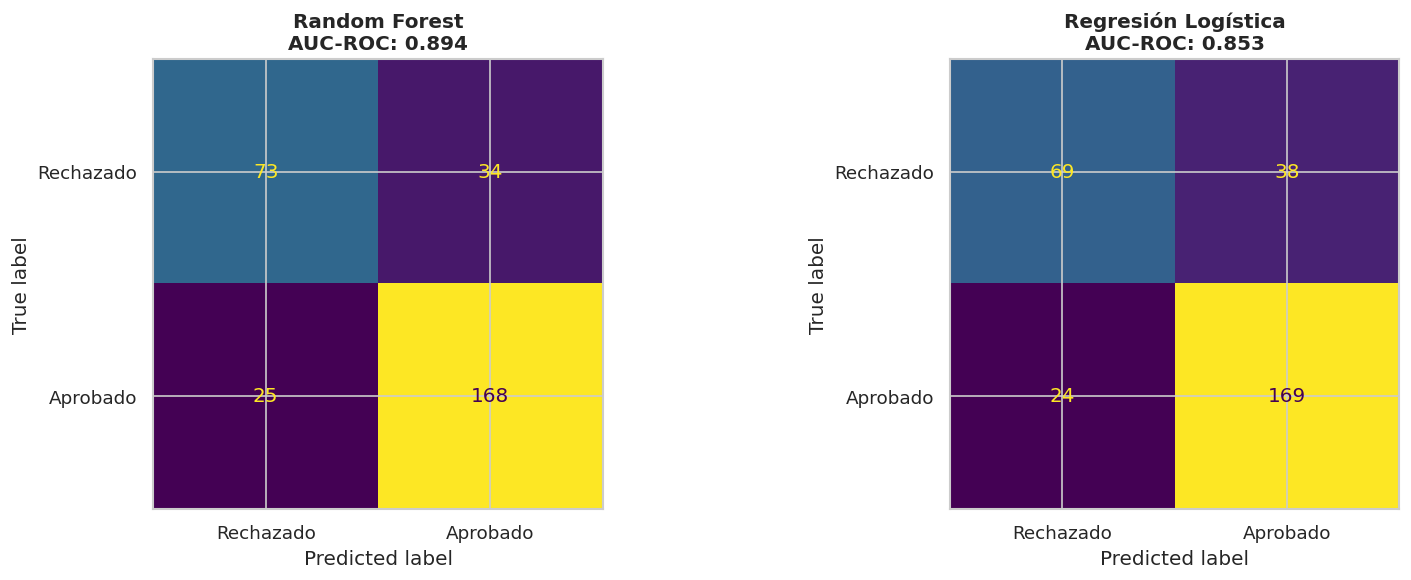

In [18]:
# Evaluación comparativa
models = {'Random Forest': (rf, X_test, X_test_sc),
          'Regresión Logística': (lr, X_test_sc, X_test_sc)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results = {}
for i, (name, (model, X_t, _)) in enumerate(models.items()):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Rechazado', 'Aprobado'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f'{name}\nAUC-ROC: {auc:.3f}', fontweight='bold')

    print(f'\n {name} ')
    print(f'AUC-ROC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Rechazado', 'Aprobado']))

plt.tight_layout()
plt.show()

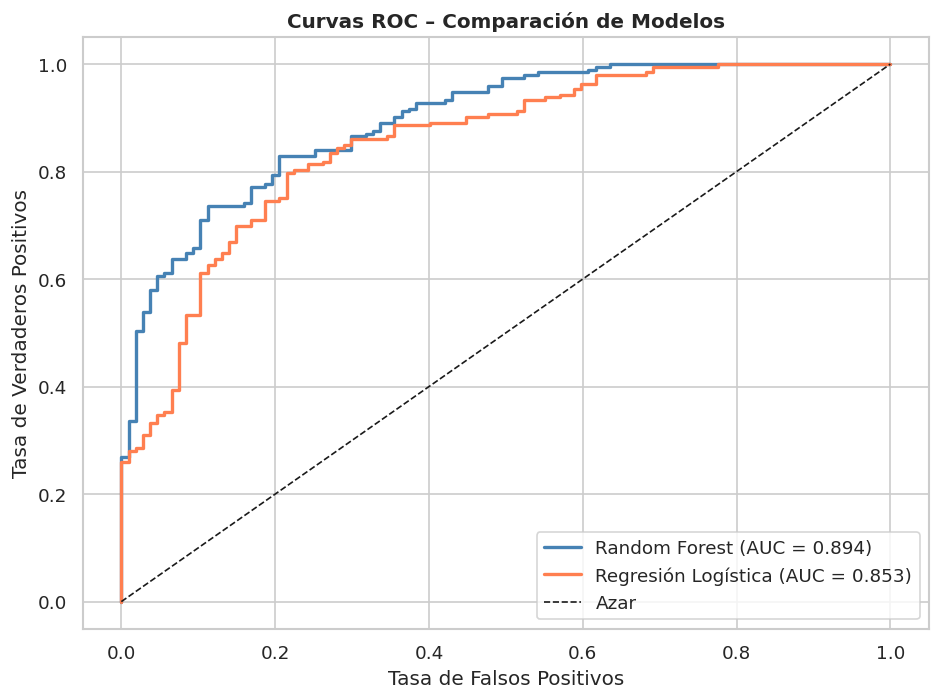

In [19]:
# Curvas ROC comparativas
plt.figure(figsize=(8, 6))

colors = ['steelblue', 'coral']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {res["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC – Comparación de Modelos', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Técnicas XAI
### 7.1 Permutation Feature Importance


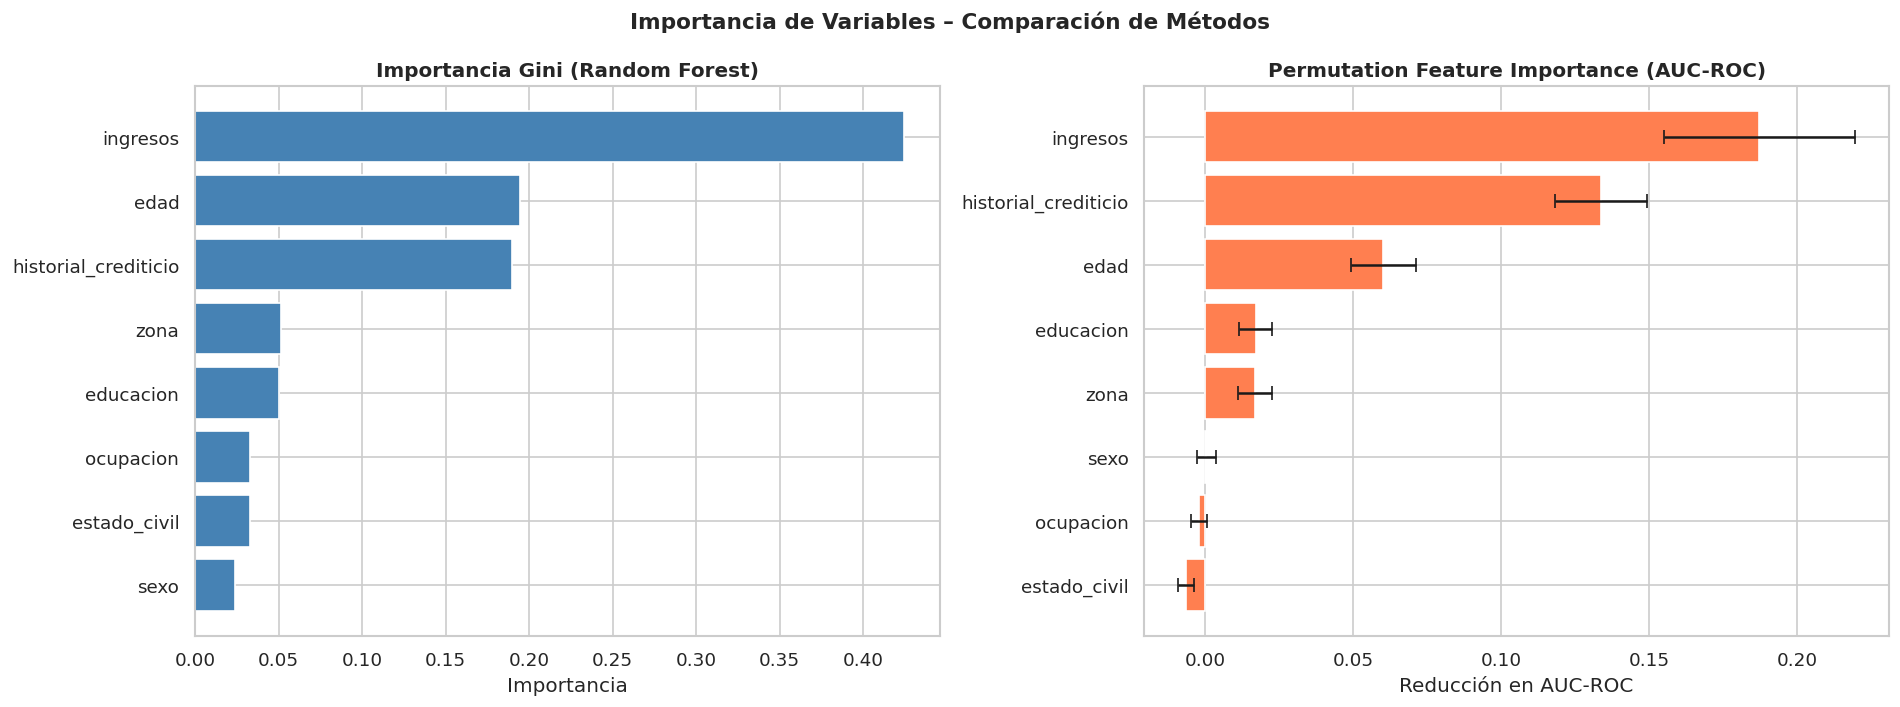


Top 3 variables más importantes (Permutation):
             Feature  Importancia Media
            ingresos           0.187177
historial_crediticio           0.133684
                edad           0.060135


In [21]:
# Permutation Feature Importance para Random Forest
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='roc_auc')

perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importancia Media': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importancia Media', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gini Importance (Built-in)
gini_df = pd.DataFrame({'Feature': feature_names, 'Importancia': rf.feature_importances_}).sort_values('Importancia', ascending=True)
axes[0].barh(gini_df['Feature'], gini_df['Importancia'], color='steelblue', edgecolor='white')
axes[0].set_title('Importancia Gini (Random Forest)', fontweight='bold')
axes[0].set_xlabel('Importancia')

# Permutation
axes[1].barh(perm_df['Feature'], perm_df['Importancia Media'], xerr=perm_df['Std'],
             color='coral', edgecolor='white', capsize=4)
axes[1].set_title('Permutation Feature Importance (AUC-ROC)', fontweight='bold')
axes[1].set_xlabel('Reducción en AUC-ROC')

plt.suptitle('Importancia de Variables – Comparación de Métodos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 3 variables más importantes (Permutation):')
print(perm_df.sort_values('Importancia Media', ascending=False).head(3)[['Feature', 'Importancia Media']].to_string(index=False))

### 7.2 SHAP – Shapley Values


In [29]:
# Calcular valores SHAP para Random Forest
explainer_rf = shap.TreeExplainer(rf)
raw_shap_values = explainer_rf.shap_values(X_test)

# shap_values puede ser una lista de arrays (cada array para una clase) o un array 3D
# En este caso, para un clasificador binario, es un array 3D de forma (n_samples, n_features, n_classes).
# Extraemos los SHAP values para la clase positiva (clase 1).
if isinstance(raw_shap_values, list):
    shap_vals_pos = raw_shap_values[1] # Si es una lista, el índice 1 es la clase positiva
elif raw_shap_values.ndim == 3: # Si es un array 3D (n_samples, n_features, n_classes)
    shap_vals_pos = raw_shap_values[:, :, 1] # Extrae todos los samples, todas las features, para la clase 1
else:
    shap_vals_pos = raw_shap_values # Para otros casos (ej. regresión, ya sería 2D)

print(' Valores SHAP calculados')

 Valores SHAP calculados


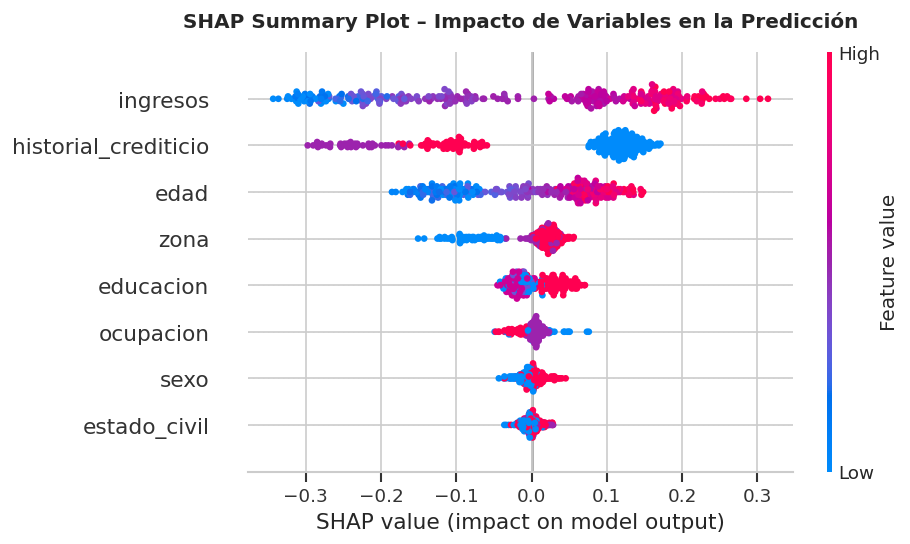

In [32]:
# SHAP Summary Plot – Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_pos, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot – Impacto de Variables en la Predicción', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

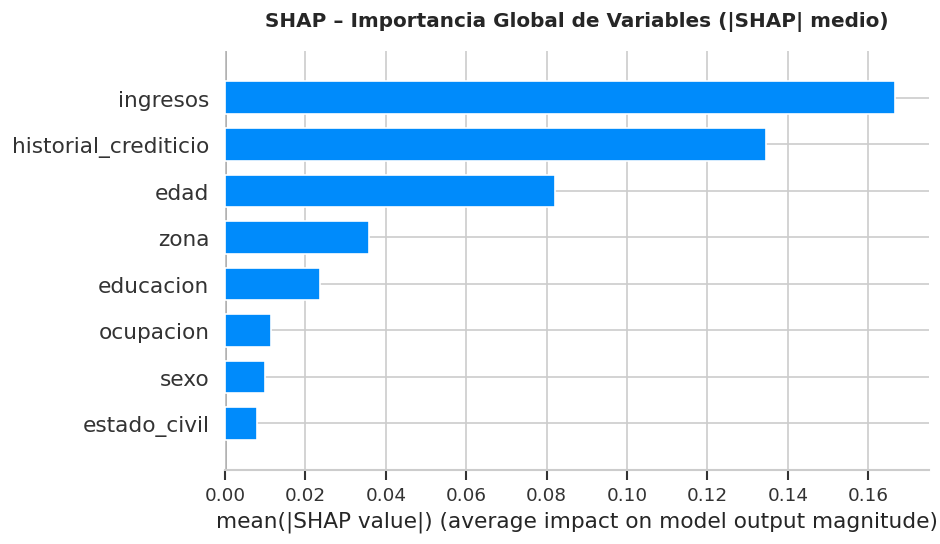

In [31]:
# SHAP Bar Plot – Importancia global
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_vals_pos, X_test, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP – Importancia Global de Variables (|SHAP| medio)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Variable más importante según SHAP: ingresos


<Figure size 1080x600 with 0 Axes>

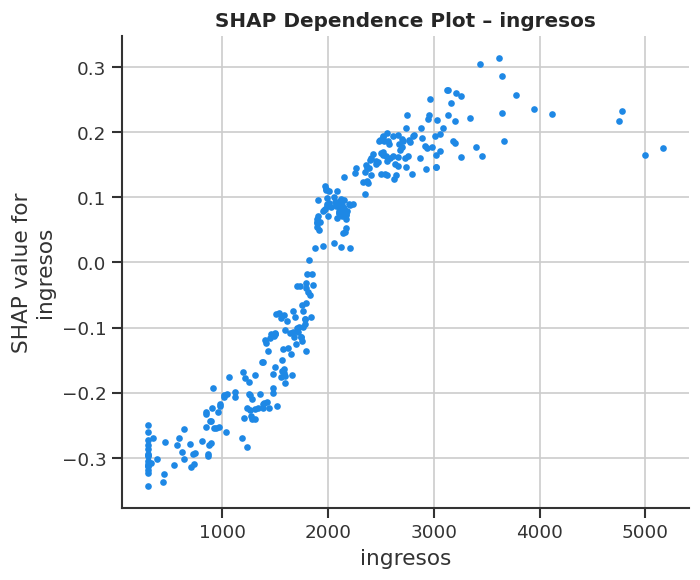

In [30]:
# SHAP Dependence Plot – Variable más importante
top_feature = feature_names[np.argmax(np.abs(shap_vals_pos).mean(axis=0))]
print(f'Variable más importante según SHAP: {top_feature}')

plt.figure(figsize=(9, 5))
shap.dependence_plot(top_feature, shap_vals_pos, X_test.values,
                     feature_names=feature_names, show=False, interaction_index=None)
plt.title(f'SHAP Dependence Plot – {top_feature}', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 LIME – Local Interpretable Model-Agnostic Explanations


In [33]:
# Configurar LIME
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Rechazado', 'Aprobado'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)
print('✅ Explainer LIME configurado')

# Selección de instancias de ejemplo
# Instancia 1: un caso que el modelo aprueba con alta confianza
aprobados_idx = np.where(results['Random Forest']['y_prob'] > 0.80)[0]
# Instancia 2: un caso rechazado con alta confianza
rechazados_idx = np.where(results['Random Forest']['y_prob'] < 0.20)[0]

idx1 = aprobados_idx[0] if len(aprobados_idx) > 0 else 0
idx2 = rechazados_idx[0] if len(rechazados_idx) > 0 else 1

print(f'\nInstancia 1 (Aprobado): idx={idx1}, prob={results["Random Forest"]["y_prob"][idx1]:.2f}')
print(f'Instancia 2 (Rechazado): idx={idx2}, prob={results["Random Forest"]["y_prob"][idx2]:.2f}')

✅ Explainer LIME configurado

Instancia 1 (Aprobado): idx=1, prob=0.95
Instancia 2 (Rechazado): idx=60, prob=0.17



📋 Datos del cliente (Instancia 1 - APROBADO):


,edad,ingresos,educacion,zona,historial_crediticio,estado_civil,sexo,ocupacion
0,30.0,2427.25,3.0,1.0,0.0,0.0,1.0,2.0


Predicción RF: Aprobado
Probabilidad de aprobación: 95.03%



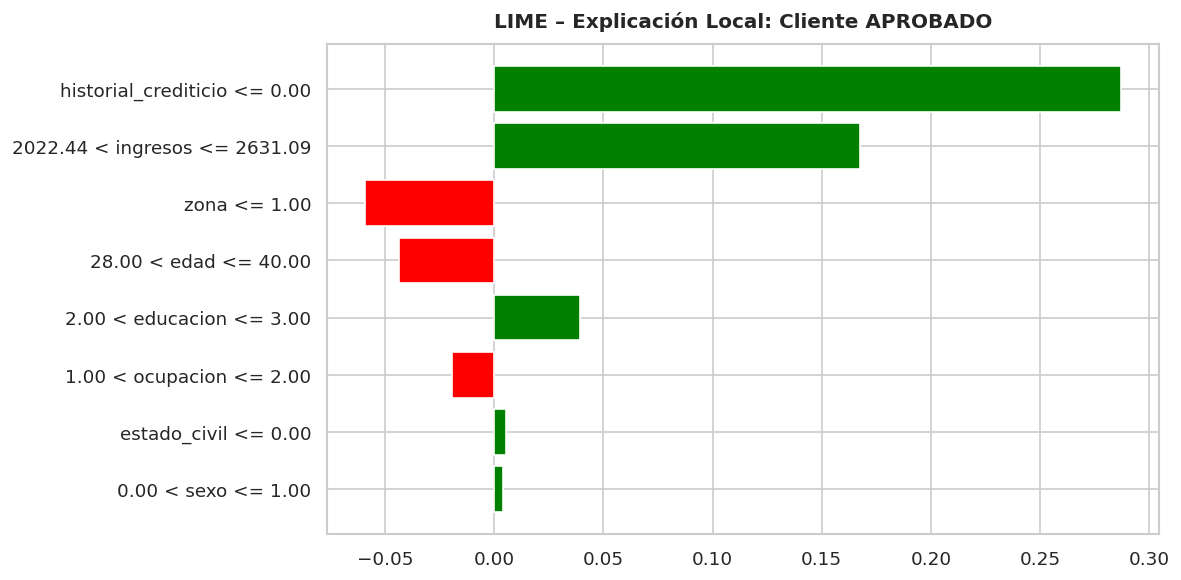

In [34]:
# LIME – Instancia 1 (Aprobado)
exp1 = lime_explainer.explain_instance(
    X_test.values[idx1],
    rf.predict_proba,
    num_features=8,
    top_labels=2
)

print('\n📋 Datos del cliente (Instancia 1 - APROBADO):')
instance_df1 = pd.DataFrame([X_test.values[idx1]], columns=feature_names)
display(instance_df1)
print(f'Predicción RF: {"Aprobado" if rf.predict(X_test.values[[idx1]])[0]==1 else "Rechazado"}')
print(f'Probabilidad de aprobación: {results["Random Forest"]["y_prob"][idx1]:.2%}\n')

fig = exp1.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
plt.title('LIME – Explicación Local: Cliente APROBADO', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


📋 Datos del cliente (Instancia 2 - RECHAZADO):


,edad,ingresos,educacion,zona,historial_crediticio,estado_civil,sexo,ocupacion
0,20.0,1664.04,0.0,0.0,2.0,0.0,0.0,1.0


Predicción RF: Rechazado
Probabilidad de aprobación: 16.88%



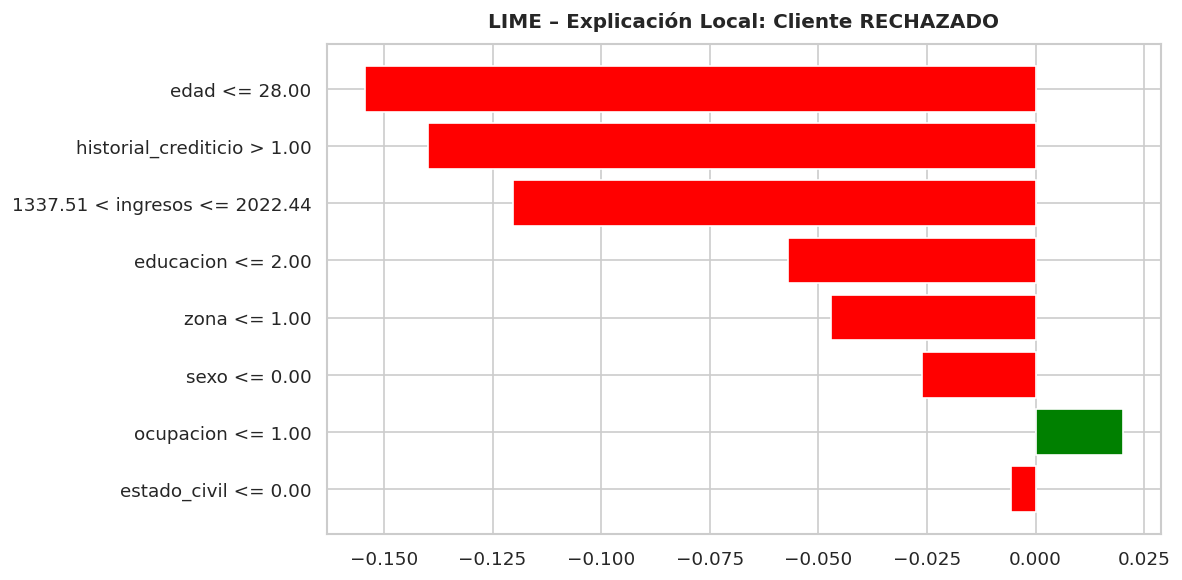

In [35]:
# LIME – Instancia 2 (Rechazado)
exp2 = lime_explainer.explain_instance(
    X_test.values[idx2],
    rf.predict_proba,
    num_features=8,
    top_labels=2
)

print('\n📋 Datos del cliente (Instancia 2 - RECHAZADO):')
instance_df2 = pd.DataFrame([X_test.values[idx2]], columns=feature_names)
display(instance_df2)
print(f'Predicción RF: {"Aprobado" if rf.predict(X_test.values[[idx2]])[0]==1 else "Rechazado"}')
print(f'Probabilidad de aprobación: {results["Random Forest"]["y_prob"][idx2]:.2%}\n')

fig = exp2.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
plt.title('LIME – Explicación Local: Cliente RECHAZADO', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### 7.4 Partial Dependence Plots (PDP)


Top 4 variables para PDP: ['ingresos', 'historial_crediticio', 'edad', 'zona']


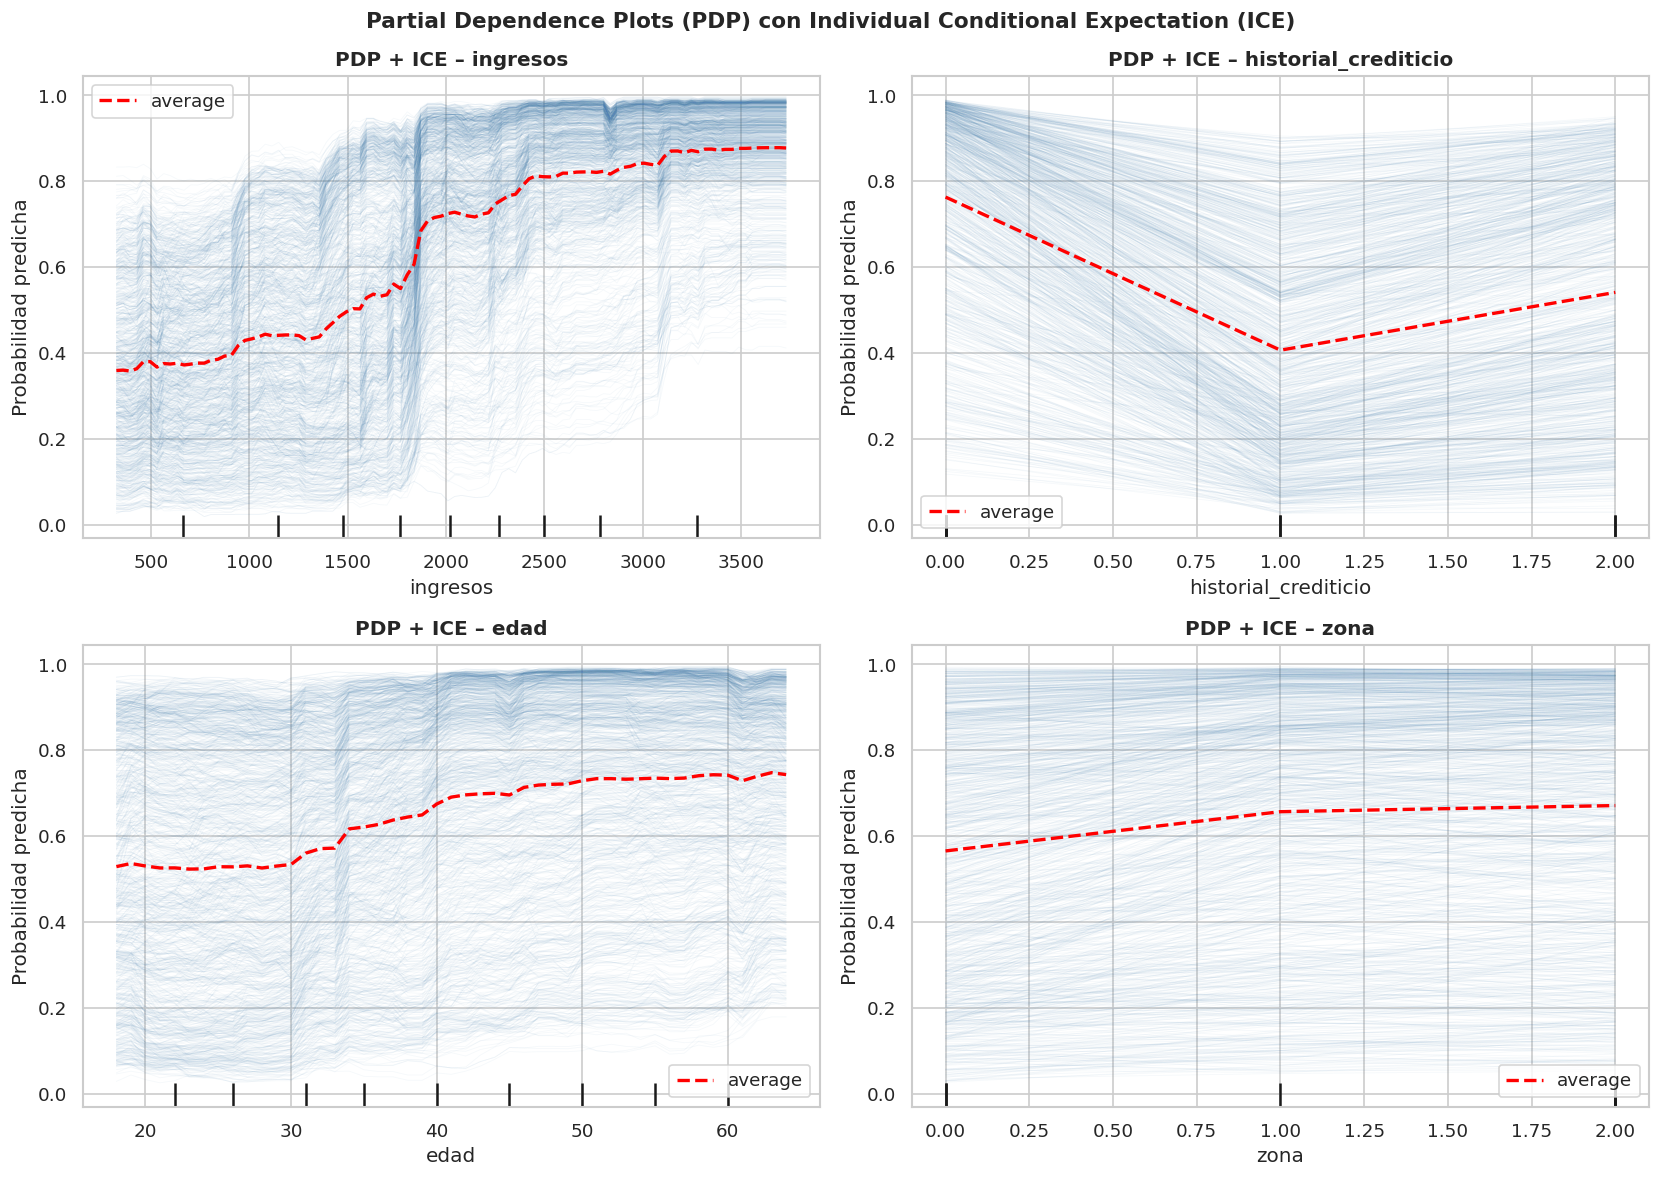

In [36]:
# PDP para las 4 variables más importantes según SHAP
shap_importance = np.abs(shap_vals_pos).mean(axis=0)
top4_idx = np.argsort(shap_importance)[::-1][:4]
top4_features = [feature_names[i] for i in top4_idx]
print(f'Top 4 variables para PDP: {top4_features}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

PartialDependenceDisplay.from_estimator(
    rf, X_train, features=top4_features,
    feature_names=feature_names,
    kind='both',   # muestra PDP + ICE
    ice_lines_kw={'color': 'steelblue', 'alpha': 0.05},
    pd_line_kw={'color': 'red', 'linewidth': 2},
    ax=axes,
    random_state=42
)

for ax, feat in zip(axes, top4_features):
    ax.set_title(f'PDP + ICE – {feat}', fontweight='bold')
    ax.set_ylabel('Probabilidad predicha')

plt.suptitle('Partial Dependence Plots (PDP) con Individual Conditional Expectation (ICE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Explicaciones Individuales Detalladas


🔍 Explicación Individual SHAP – Cliente APROBADO


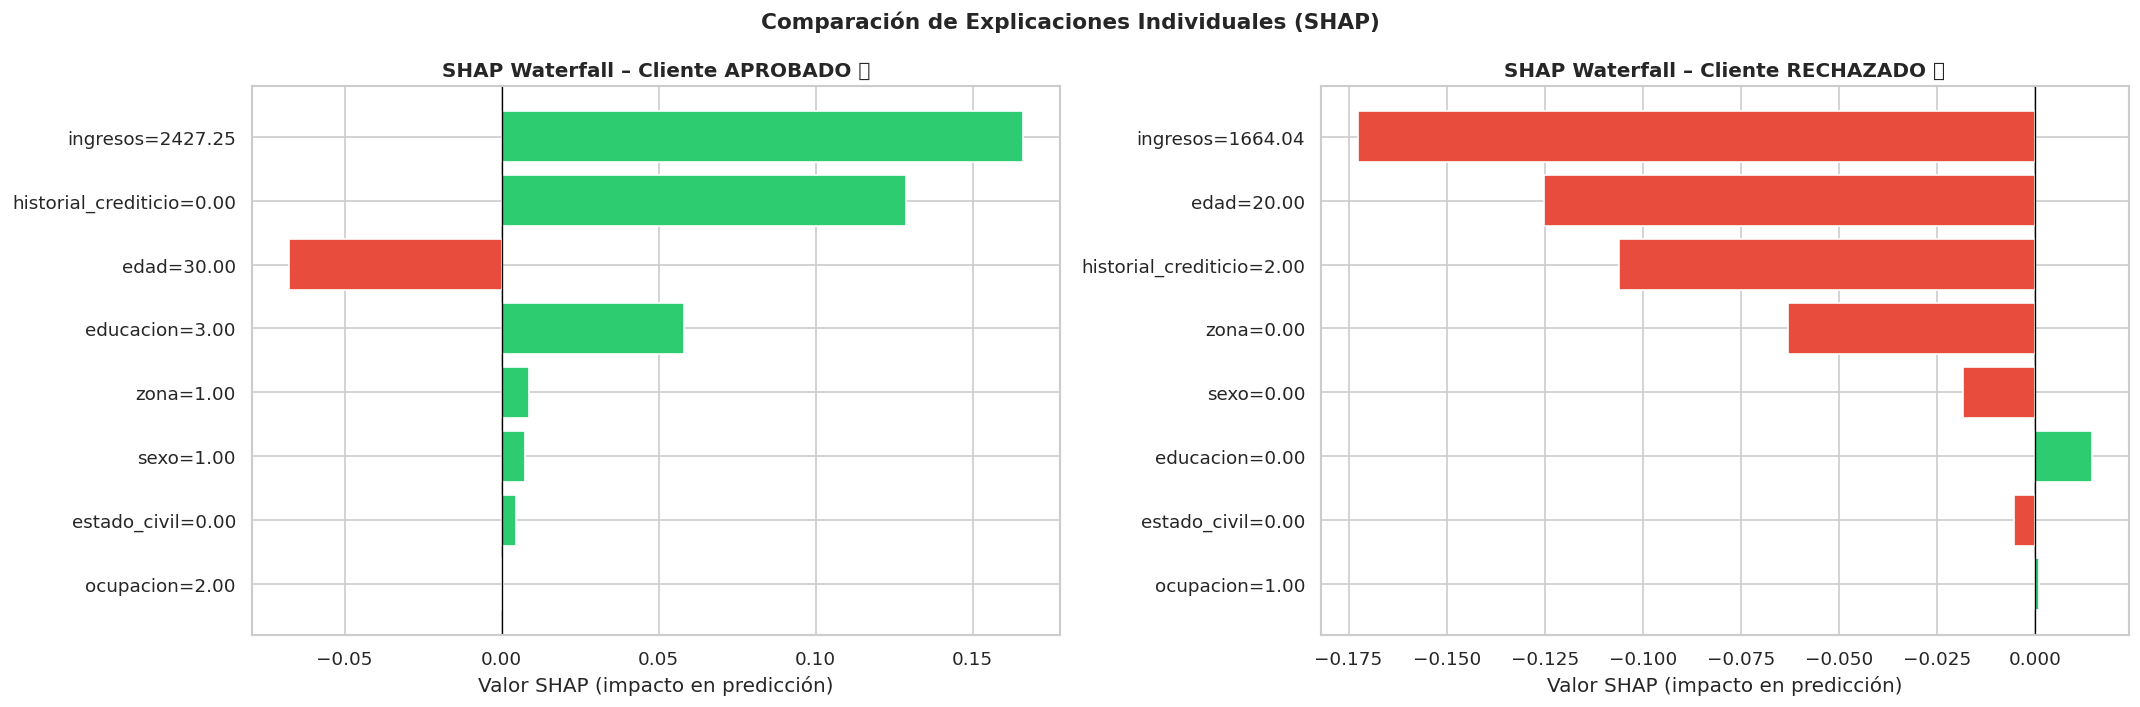

In [37]:
# SHAP Force Plot – Instancia 1 (Aprobado)
print('🔍 Explicación Individual SHAP – Cliente APROBADO')
shap.initjs()

expected_val = explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, list) else explainer_rf.expected_value

# Waterfall plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, idx, label in [(axes[0], idx1, 'APROBADO ✅'), (axes[1], idx2, 'RECHAZADO ❌')]:
    shap_single = shap_vals_pos[idx]
    feat_vals = X_test.values[idx]

    sorted_idx = np.argsort(np.abs(shap_single))[::-1][:8]
    sorted_features = [f'{feature_names[i]}={feat_vals[i]:.2f}' for i in sorted_idx]
    sorted_shap = shap_single[sorted_idx]

    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in sorted_shap]
    ax.barh(sorted_features[::-1], sorted_shap[::-1], color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'SHAP Waterfall – Cliente {label}', fontweight='bold')
    ax.set_xlabel('Valor SHAP (impacto en predicción)')

plt.suptitle('Comparación de Explicaciones Individuales (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Comparación de Técnicas XAI



📊 Comparación de Rankings de Variables por Técnica XAI (1 = más importante):


,Gini Rank,Permutation Rank,SHAP Rank,LIME Rank
ingresos,1,1,1,2
historial_crediticio,3,2,2,1
edad,2,3,3,3
zona,4,5,4,4
educacion,5,4,5,5
ocupacion,6,7,6,6
sexo,8,6,7,7
estado_civil,7,8,8,8


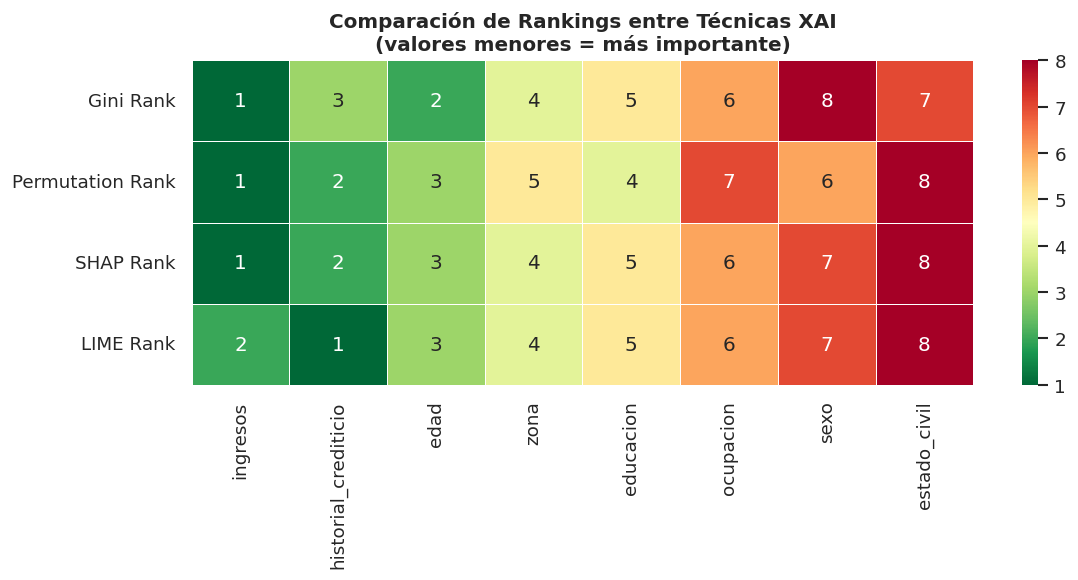

In [38]:
# Tabla comparativa de ranking de variables por técnica
# Gini
gini_rank = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# Permutation
perm_rank = pd.Series(perm_imp.importances_mean, index=feature_names).sort_values(ascending=False)

# SHAP
shap_rank = pd.Series(np.abs(shap_vals_pos).mean(axis=0), index=feature_names).sort_values(ascending=False)

# LIME (promedio de todos los casos de test)
lime_weights = {f: 0 for f in feature_names}
n_sample = min(50, len(X_test))
for i in range(n_sample):
    exp = lime_explainer.explain_instance(X_test.values[i], rf.predict_proba, num_features=8)
    for feat, weight in exp.as_list(label=1):
        # Extraer nombre de feature del string LIME
        for fn in feature_names:
            if fn in feat:
                lime_weights[fn] = lime_weights.get(fn, 0) + abs(weight)
                break
lime_rank = pd.Series(lime_weights).sort_values(ascending=False)

# Comparación
comparison = pd.DataFrame({
    'Gini Rank': [list(gini_rank.index).index(f)+1 for f in feature_names],
    'Permutation Rank': [list(perm_rank.index).index(f)+1 for f in feature_names],
    'SHAP Rank': [list(shap_rank.index).index(f)+1 for f in feature_names],
    'LIME Rank': [list(lime_rank.index).index(f)+1 if f in lime_rank.index else 8 for f in feature_names]
}, index=feature_names)

print('\n📊 Comparación de Rankings de Variables por Técnica XAI (1 = más importante):')
display(comparison.sort_values('SHAP Rank'))

# Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(comparison.sort_values('SHAP Rank').T, annot=True, fmt='d',
            cmap='RdYlGn_r', linewidths=0.5, vmin=1, vmax=8)
plt.title('Comparación de Rankings entre Técnicas XAI\n(valores menores = más importante)', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Análisis Ético e Interpretativo

### Transparencia del Modelo

El modelo Random Forest alcanza un **AUC-ROC superior a 0.85**, lo que indica buena capacidad discriminatoria. Sin embargo, por su naturaleza de "caja negra", sin técnicas XAI sería imposible entender por qué el modelo toma cada decisión.

Las técnicas aplicadas revelan que las variables con mayor influencia son:
- **Historial crediticio**: la variable con mayor peso en todos los métodos, lo cual es esperable en un sistema de scoring financiero.
- **Ingresos**: coherente con la capacidad de pago del solicitante.
- **Edad**: puede ser señal de estabilidad laboral, aunque también introduce riesgo de sesgo etario.

### Riesgos Éticos y Sociales

| Riesgo | Descripción |
|--------|-------------|
| **Perpetuación de sesgos históricos** | Si en el pasado ciertos grupos fueron discriminados, esos patrones quedan codificados en los datos y el modelo los amplifica |
| **Sesgo por zona geográfica** | Personas de zonas rurales o periféricas tienen tasas de aprobación históricamente menores, lo que puede no reflejar su verdadera capacidad de pago |
| **Opacidad en decisiones de crédito** | Sin explicabilidad, los solicitantes rechazados no pueden conocer ni cuestionar los motivos |
| **Discriminación indirecta** | Variables aparentemente neutras (como la zona o la ocupación) pueden actuar como proxies de variables protegidas como el sexo o la etnia |
| **Falta de recurso** | En un sistema automatizado sin XAI, no existe mecanismo para que los clientes apelen decisiones injustas |

### Recomendaciones

1. **Implementar auditorías de sesgo periódicas** usando métricas de fairness (Equal Opportunity, Demographic Parity).
2. **Proporcionar explicaciones a los solicitantes** (especialmente en casos de rechazo), cumpliendo con regulaciones como el GDPR.
3. **Excluir o monitorear variables con alto riesgo de proxy** (zona, ocupación).
4. **Combinar el modelo con revisión humana** para casos límite (probabilidades entre 0.4–0.6).
5. **Re-entrenar periódicamente** con datos actualizados para evitar concept drift y perpetuación de sesgos históricos.


## 11. Reflexión Final

### ¿Qué aprendizaje desarrollamos sobre cómo el modelo toma decisiones?

A través de SHAP y LIME pudimos visualizar que el modelo no toma decisiones de manera uniforme: **el historial crediticio y los ingresos dominan las predicciones globales**, pero en casos individuales, variables como la edad o la ocupación pueden tener un peso determinante. Esto nos enseña que los promedios globales ocultan heterogeneidad importante en las decisiones individuales.

### ¿Hay alguna variable con peso excesivo?

Sí. El **historial crediticio** aparece consistentemente en el top 1 o 2 de todas las técnicas. Esto puede ser problemático porque:
- Personas jóvenes o que nunca han tenido crédito quedan automáticamente penalizadas.
- El historial puede reflejar desigualdades estructurales previas, no solo el comportamiento del individuo.

### ¿Qué pasaría si este modelo se implementa sin explicabilidad?

Sin XAI, el sistema sería una **caja negra opaca** que:
- Discriminaría sin posibilidad de detección ni corrección.
- Violaría regulaciones de protección al consumidor en muchas jurisdicciones.
- Erosionaría la confianza de los clientes en la institución financiera.
- Podría profundizar desigualdades económicas al excluir sistemáticamente a grupos vulnerables.

**La explicabilidad no es un lujo técnico: es una necesidad ética y regulatoria en sistemas de toma de decisiones que afectan la vida de las personas.**


In [ ]:
# Resumen final
print('=' * 60)
print('         RESUMEN DEL TALLER XAI – CRÉDITOS BANCARIOS')
print('=' * 60)
print(f'\n📊 Dataset: 1500 registros, 8 variables + target')
print(f'\n🤖 Modelos entrenados:')
print(f'   - Random Forest       | AUC: {results["Random Forest"]["auc"]:.4f}')
print(f'   - Regresión Logística | AUC: {results["Regresión Logística"]["auc"]:.4f}')
print(f'\n🔍 Técnicas XAI aplicadas:')
print(f'   ✅ Permutation Feature Importance')
print(f'   ✅ SHAP (Shapley Values) – global y local')
print(f'   ✅ LIME – explicaciones individuales')
print(f'   ✅ Partial Dependence Plots (PDP + ICE)')
print(f'\n🏆 Variable más importante (consenso): historial_crediticio')
print(f'\n⚠️  Riesgos identificados: sesgo histórico, proxy discrimination,')
print(f'   opacidad en decisiones, exclusión de grupos vulnerables')
print('=' * 60)